# What the robustness fixes changed: legacy vs fresh

`CHANGES_NEEDED.md` §4.2 phase 7 and §6 require one deliverable in writing: **the differences
from the legacy tables**.  This notebook computes them; the written account is
[`analysis/WHAT_CHANGED.md`](WHAT_CHANGED.md).  The helper module is `analysis/legacy_diff.py`
— this notebook only drives it, renders the tables and exports them to `analysis/tables/legacy/`
(markdown + LaTeX) and the figures to `plots_v2/legacy_vs_fresh/`.

**Two roots.** `experiment_results_legacy_2026-09-18/` (read-only, pre-campaign) against
`experiment_results/` (schema 2).  Every scan directory that exists in both is treated here;
§1.1b lists what is **outside** that intersection, because seven legacy scans have no fresh
counterpart and four of them backed legacy figures that now rest on nothing.

**Three rules that make the two sides comparable.**

1. *The legacy metric is the example-weighted repair*, not the number the legacy run recorded:
   the legacy loops averaged per-batch means, so the last, short validation batch carried the
   weight of a full one (F10). `analysis/repair_legacy.py` recomputes the curves exactly from
   the stored per-batch losses; this notebook joins `final_val_loss_ew` on `run_id`.
2. *The selection rule is the same on both sides* — eligible → fewest diverged → seed-mean
   final **validation** loss (`CHANGES_NEEDED.md` §1, `scan_analysis.Scan.configs`). The fresh
   headline numbers are not re-selected at all: they come from the selection of record
   (`bench/best_configs.json`) through `analysis/headline.py`. The gate in §1.2 proves that
   this module's own rule reproduces that file before any table below is believed.
3. *Polynomial scans compare ranks only.* The legacy `RandomPolynomialDataset` adds its factors
   instead of multiplying them and omits the constant, linear and pure degree-*d* monomials: it
   is an additive cubic (F1/C-D1). A loss on it is not a loss on the fresh degree-4 target.

**What a rank is a rank in, and what it is computed on.** The fresh campaign added
baselines (SGDm everywhere; AdamW/Muon/MuonW/SOAP on CIFAR; KFAC on MNIST), so the field grew.
Every table therefore gives *two* fresh ranks: the like-for-like rank among the methods **both**
campaigns ran, and the rank in the full fresh field, which is the number the paper quotes. A
fresh rank is a rank on the **confirmation** mean — except where that configuration is not
eligible on the confirmation seeds (polynomial L-BFGS finishes 2 of 15, and a mean over two
survivors is not the method's loss), where the rule falls back to the tuning-seed loss. Such a
rank is then a rank on a *different number* than the confirmation mean printed beside it, so
`diff_view` marks it `*` and gives its basis in its own column. **Sven is eligible on the
confirmation seeds of all seven headline scans**, so no statement about Sven here rests on that
fallback; §2 asserts it.

**Aggregates are never pooled across targets.** The polynomial rows are ranks on the legacy
*additive cubic*, and they are also Sven's largest rank gains. §6 therefore reports the
same-target points and the ranks-only points separately and never adds them up.

**Conventions** (binding, `campaign/ANALYSIS_CONTRACTS.md`): diverged = failed, never in a mean,
always counted; `finished / attempted` on every table; a ± band is 1 std (ddof=1) over seeds;
test metrics are outcomes, never selectors; display names from `style.method_label`.

## 1. Setup and the gates this notebook refuses to run without

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import headline as hl
import legacy_diff as ld
import style
from style import set_style

set_style()
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 90)

TABLES = 'legacy'                       # analysis/tables/legacy/
ld.PLOT_DIR.mkdir(parents=True, exist_ok=True)
(hl.TABLES_DIR / TABLES).mkdir(parents=True, exist_ok=True)
print(f'legacy root : {ld.LEGACY_ROOT}')
print(f'fresh root  : {style.RESULTS_ROOT}')
print(f'repairs     : {ld.RL.OUT_DIR}')
print(f'plots  -> {ld.PLOT_DIR}')
print(f'tables -> {hl.TABLES_DIR / TABLES}')

legacy root : /n/home11/sambt/iaifi/sv3/experiment_results_legacy_2026-09-18
fresh root  : ../experiment_results
repairs     : /n/home11/sambt/iaifi/sv3/analysis/legacy_repair
plots  -> /n/home11/sambt/iaifi/sv3/analysis/plots_v2/legacy_vs_fresh
tables -> /n/home11/sambt/iaifi/sv3/analysis/tables/legacy


### 1.1 Every scan that exists in both roots, and how it is compared

A scan is compared in one of three ways, and the classification is exhaustive: the assertion
below fails if a scan directory appears in both roots and this notebook has no rule for it.

In [2]:
both = ld.scans_in_both_roots()
inv = pd.DataFrame([{
    'scan': s, 'title': ld.scan_title(s), 'compared as': ld.scan_kind(s),
    'axis': ld.GROUPED_SCANS.get(s, ld.SVEN_ONLY_SCANS.get(s, '')),
    'ranks only': ld.ranks_only(s),
    'note': ld.EXCLUDED.get(s, ''),
} for s in both])
hl.print_table(inv, f'{len(both)} scan directories exist in BOTH results roots')
unclassified = inv[inv['compared as'] == 'unclassified']
assert unclassified.empty, f'no comparison rule for {list(unclassified["scan"])}'
print(f"\nheadline {int((inv['compared as'] == 'headline').sum())}, "
      f"grouped {int((inv['compared as'] == 'grouped').sum())}, "
      f"Sven-only {int((inv['compared as'] == 'sven_only').sum())}, "
      f"excluded {int((inv['compared as'] == 'excluded').sum())}")


### 27 scan directories exist in BOTH results roots
| scan | title | compared as | axis | ranks only | note |
|---|---|---|---|---|---|
| cifar10_resnet_ce_scan | CIFAR-10 (CE) | headline |  | False |  |
| cifar10_resnet_scan_labelRegression | CIFAR-10 (label reg.) | headline |  | False |  |
| exp_gpt2_small_comparison | GPT-2 small (FineWeb) | excluded |  | False | legacy GPT-2 trained on a corpus whose validation set is a prefix of training (F4/C-D2) and has 6 runs against 29: not a comparison, a quarantine |
| exp_nanogpt_speedrun | nanoGPT (tiny-shakespeare) | headline |  | False |  |
| exp_nanogpt_speedrun_timing | exp_nanogpt_speedrun_timing | excluded |  | False | standalone timing pass, not a tuning grid |
| mnist_kappaScan_labelRegression | MNIST (label reg.), kappa | sven_only | kappa | False |  |
| mnist_microbatch_ce_scan | MNIST (CE), micro-batch | sven_only | microbatch_size | False |  |
| mnist_microbatch_labelreg_scan | MNIST (label reg.), micro-batch | sven_only | mic

### 1.1b What is **not** in the intersection

The table above is an intersection of the two roots, so anything outside it silently
disappears from this account. This is the complement. A fresh-only directory is an auxiliary
**pass** the fresh protocol added (`_confirm` / `_diag` / `_timing`) and the legacy campaign
has no equivalent of — the fresh campaign added no new standalone scan. A legacy-only
directory is a legacy result with **no fresh counterpart at all**, and each one's disposition
is quoted from `EXPERIMENTS.md` §10 and `campaign/CONTRACTS.md`, not decided here: four of
them back legacy paper/rebuttal figures that now rest on nothing.

In [3]:
INV = ld.scan_inventory()
outside = INV[INV['where'] != 'both']
hl.print_table(outside[['scan', 'where', 'n_records_leg', 'n_records_fresh',
                        'disposition']],
               f"{INV.attrs['n_legacy_only']} legacy-only and {INV.attrs['n_fresh_only']} "
               f"fresh-only scan directories ({INV.attrs['n_both']} in both)")
hl.write_table(INV, 'legacy_diff_scan_inventory', subdir=TABLES)

leg_only = INV[INV['where'] == 'legacy only']
missing = [s for s in leg_only['scan'] if s not in ld.LEGACY_ONLY_DISPOSITION]
assert not missing, f'legacy-only scans with no recorded disposition: {missing}'
print(f"\n{len(leg_only)} legacy scan directories ({int(leg_only['n_records_leg'].sum())} "
      f"records) have no fresh counterpart:")
for _, r in leg_only.iterrows():
    print(f"  {r['scan']} ({r['n_records_leg']} runs): {r['disposition']}")
no_fresh = [s for s, d in ld.LEGACY_ONLY_DISPOSITION.items() if 'NO fresh' in d]
print(f"\n{len(no_fresh)} of them have NO fresh data on the question they asked "
      f"({', '.join(no_fresh)}): the legacy critical-batch-size study, the CIFAR kappa set "
      f"point, the CIFAR cross-entropy parameter-fraction curve and the small-N fine-tuning "
      f"experiment cannot be quoted from the fresh campaign at all. The remaining two CIFAR "
      f"parameter-fraction scans are superseded by rebuttal_fig5_cifar_paramfrac_scan, "
      f"which exists in both roots and is diffed in §5.")
passes = INV[(INV['where'] == 'fresh only') & (INV['disposition'] != '')]
assert len(passes) == INV.attrs['n_fresh_only'], (
    'a fresh-only directory is not a pass of a headline scan: it is a new scan with no '
    'legacy counterpart and needs a disposition of its own')
print(f"\nall {INV.attrs['n_fresh_only']} fresh-only directories are confirm / diag / "
      f"timing passes of the seven headline scans, not new experiments.")


### 7 legacy-only and 16 fresh-only scan directories (27 in both)
| scan | where | n_records_leg | n_records_fresh | disposition |
|---|---|---|---|---|
| cifar10_resnet_ce_kappaScan | legacy only | 2 | 0 | CUT: 1 seed at a tentative set point; replaced on MNIST only (mnist_kappaScan_labelRegression). NO fresh CIFAR kappa scan. |
| cifar10_resnet_ce_paramFrac_scan | legacy only | 6 | 0 | CUT: superseded by rebuttal_fig5_cifar_paramfrac_scan (label regression only), so the cross-entropy parameter-fraction curve has NO fresh counterpart. |
| cifar10_resnet_ce_scan_confirm | fresh only | 0 | 55 | confirm pass of cifar10_resnet_ce_scan |
| cifar10_resnet_ce_scan_diag | fresh only | 0 | 55 | diag pass of cifar10_resnet_ce_scan |
| cifar10_resnet_ce_scan_timing | fresh only | 0 | 55 | timing pass of cifar10_resnet_ce_scan |
| cifar10_resnet_kappaScan_labelReg | legacy only | 5 | 0 | CUT: 1 seed at a tentative set point. The kappa story now runs on MNIST at 5 seeds with a matched-effective-s

### 1.2 Gate: does this module's rule reproduce the selection of record?

The legacy root has no selection file, so the only evidence that the legacy winners were picked
by the *same* rule as the fresh ones is to run this module's code path on the **fresh** scans and
diff it against `bench/best_configs.json`. A disagreement is allowed only where the scan is
still moving (§1.3): a scan whose grid has grown since the selection was written is
**provisional**, and re-running this notebook after `tools/select_best.py` updates every cell
that mentions it.

In [4]:
agree = ld.selection_agreement()
n_ok = int(agree['agrees'].sum())
print(f"{n_ok} of {len(agree)} (scan, method) selections reproduce from this module's rule "
      f"(max rel. difference {np.nanmax(agree['rel_diff']):.2e})")
bad = agree[~agree['agrees']]
if len(bad):
    print('\nDISAGREEMENTS:')
    print(bad.to_string(index=False))

Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)


toy_1d_scan: 1770 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-06, 1e-05, 0.0001, 0.001, 0.01]
  289 diverged run(s), excluded from seed means: {'SVD': 194, 'LBFGS': 52, 'KFAC': 19, 'HIG': 11, 'SGD': 5, 'SGDm': 5, 'SOAP': 3}
  manifest: 1770 of 1770 intended runs present, 0 with no record


Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)


polynomial_scan: 1630 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1]
  260 diverged run(s), excluded from seed means: {'LBFGS': 204, 'KFAC': 21, 'SGDm': 12, 'SGD': 8, 'SOAP': 4, 'SVD': 4, 'HIG': 3, 'RMSprop': 3, 'MuonW': 1}
  manifest: 1630 of 1630 intended runs present, 0 with no record


Loaded 1360 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)


...

Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)


mnist_scan_ce: 1610 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32, 48, 64] rtol=[0.0001, 0.001, 0.01, 0.1, 0.3]
  131 diverged run(s), excluded from seed means: {'LBFGS': 70, 'KFAC': 40, 'SOAP': 9, 'SGDm': 5, 'MuonW': 3, 'SGD': 3, 'RMSprop': 1}
  manifest: 1610 of 1610 intended runs present, 0 with no record


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
cifar10_resnet_scan_labelRegression: 600 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01]
  33 diverged run(s), excluded from seed means: {'SGDm': 15, 'SGD': 13, 'SVD': 5}
  manifest: 600 of 600 intended runs present, 0 with no record


Loaded 775 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
cifar10_resnet_ce_scan: 775 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01, 0.03, 0.1, 0.3]
  11 diverged run(s), excluded from seed means: {'RMSprop': 8, 'SOAP': 1, 'Muon': 1, 'SGDm': 1}
  manifest: 775 of 635 intended runs present, 10 with no record
    first missing: ['svd_bs128_k128_lr0.05_rtol0.03_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.1_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.3_svdtorch_mseed4004_lseed4000_gram_bnbatch']


Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 140 runs  |  B=64, 50 epochs, 5 seeds  |  Sven k=[64] rtol=[0.001]
  manifest: 140 of 140 intended runs present, 0 with no record
84 of 85 (scan, method) selections reproduce from this module's rule (max rel. difference 3.50e-02)

DISAGREEMENTS:
                  scan method  val_mine  val_selection  rel_diff  agrees
cifar10_resnet_ce_scan   Sven  1.353719       1.402812  0.034996   False


In [5]:
# Is the selection of record still the selection of what is on disk?  `freshness_report`
# compares every record's timestamp against the moment bench/best_configs.json was written and
# counts live claims; a scan it flags is still being extended, and its tables below are
# PROVISIONAL.
fresh = hl.freshness_report()
hl.print_table(fresh, f"Freshness against the selection written "
                      f"{fresh.attrs['selection_generated_at']}")
PROVISIONAL = set(fresh.attrs['provisional_scans'])
if PROVISIONAL:
    print('\n' + '!' * 78)
    for scan in PROVISIONAL:
        print(f'PROVISIONAL: {ld.scan_title(scan)} ({scan}) is still moving — every number '
              f'for it below must be regenerated after tools/select_best.py is re-run.')
    print('!' * 78)
else:
    print('\n[ok] no scan has runs in flight')

# The two signals must agree: a selection that does not reproduce is a selection whose scan
# has changed underneath it, not a difference of rule.
drift = set(bad['scan'])
assert drift <= PROVISIONAL, (f'{sorted(drift - PROVISIONAL)} disagree with the selection of '
                              f'record but are NOT flagged as still moving: the rule itself '
                              f'has drifted')
print(f'\n[ok] selection drift ({sorted(drift) or "none"}) is confined to the provisional '
      f'scans ({sorted(PROVISIONAL) or "none"})')


### Freshness against the selection written 2026-09-20T03:58:14-0400
| scan | pass | selection_input | n_records | newest_record | n_after_selection | n_claims_live | provisional |
|---|---|---|---|---|---|---|---|
| toy_1d_scan | scan | True | 1770 | 2026-09-20 04:26:06 | 0 | 0 | False |
| toy_1d_scan | confirm | False | 225 | 2026-09-20 08:18:48 | 225 | 0 | False |
| toy_1d_scan | timing | False | 75 | 2026-09-20 09:08:05 | 75 | 0 | False |
| polynomial_scan | scan | True | 1630 | 2026-09-20 04:10:03 | 0 | 0 | False |
| polynomial_scan | confirm | False | 225 | 2026-09-20 08:33:38 | 225 | 0 | False |
| polynomial_scan | timing | False | 75 | 2026-09-20 09:06:08 | 75 | 0 | False |
| mnist_scan_labelRegression | scan | True | 1360 | 2026-09-19 19:14:25 | 0 | 0 | False |
| mnist_scan_labelRegression | confirm | False | 70 | 2026-09-20 10:32:34 | 70 | 0 | False |
| mnist_scan_labelRegression | timing | False | 70 | 2026-09-20 14:39:44 | 70 | 0 | False |
| mnist_scan_ce | scan | True | 1

### 1.3 The example-weighted repair of the legacy losses

`analysis/legacy_repair/corrections.csv` is written by `analysis/repair_legacy.py`: the size of
the batch-weighting error it removes, per scan. The repair is *exact* — the equal-weight mean of
the same per-batch blocks reproduces the stored curve (`eq_check_max` = 0 everywhere) — so this
is a correction, not an estimate. It is small on the headline scans (0.06–0.42 % median) and
large where the validation batch count is small relative to the last, short batch: the masked
CIFAR Fig-5 runs move by a median of 8.6 % and up to 53 %.

In [6]:
corr = pd.read_csv(ld.RL.OUT_DIR / 'corrections.csv')
corr = corr.assign(title=[ld.scan_title(s) for s in corr['scan']]) \
           .sort_values('median_%', ascending=False)
hl.print_table(corr[['scan', 'n_runs', 'n_scored', 'batch_sizes', 'median_%', 'p95_%',
                     'max_%', 'eq_check_max', 'n_errors']],
               'Example-weighted repair of the legacy validation losses (relative, %)')
assert (corr['eq_check_max'].fillna(0) < 2e-5).all(), 'a repair does not reproduce its record'
print(f"\n{len(corr)} legacy scans repaired; every one reproduces its stored (equal-weight) "
      f"curve to < 2e-5, so the example-weighted column is exact.")


### Example-weighted repair of the legacy validation losses (relative, %)
| scan | n_runs | n_scored | batch_sizes | median_% | p95_% | max_% | eq_check_max | n_errors |
|---|---|---|---|---|---|---|---|---|
| rebuttal_fig5_cifar_paramfrac_scan | 15 | 15 | 128 | 8.581 | 43.28 | 52.69 | 0 | 0 |
| mnist_kappaScan_labelRegression | 15 | 15 | 64 | 0.4446 | 0.4667 | 0.4676 | 0 | 0 |
| mnist_microbatch_ce_scan | 140 | 140 | 64 | 0.4202 | 0.4794 | 0.4799 | 0 | 0 |
| mnist_scan_ce | 1040 | 1010 | 64 | 0.4164 | 0.48 | 0.7795 | 0 | 0 |
| mnist_microbatch_labelreg_scan | 140 | 140 | 64 | 0.3817 | 0.4578 | 0.4686 | 0 | 0 |
| mnist_paramfrac_ce_scan | 92 | 92 | 64 | 0.3603 | 0.4723 | 0.4789 | 0 | 0 |
| exp_nanogpt_speedrun | 100 | 100 | 64 | 0.345 | 0.5369 | 0.6469 | 0 | 0 |
| mnist_paramfrac_labelreg_scan | 87 | 87 | 64 | 0.3426 | 0.4663 | 0.48 | 0 | 0 |
| mnist_scan_labelRegression | 999 | 902 | 64 | 0.2777 | 0.4574 | 0.5951 | 0 | 0 |
| rebuttal_overparam_polynomial_scan | 2160 | 2160 | 170,340,

## 2. The headline scans

One table per scan: the legacy winner of every method under the legacy data and the same rule,
then the fresh winner from the selection of record with its tuning-seed and confirmation-seed
numbers, the rank in each field, the change, the size of the grid that was searched, and the
attributed causes.

In [7]:
DIFFS, COVERAGE, FAILVIS, COMPLETE, ADAMW = {}, {}, {}, {}, {}

for scan in ld.HEADLINE_SCANS:
    leg, cov = ld.load_side(scan, legacy=True)
    fre, _ = ld.load_side(scan, legacy=False)
    COVERAGE[scan] = dict(cov, scan=scan, title=ld.scan_title(scan))
    DIFFS[scan] = ld.diff_table(scan, legacy=leg, fresh=fre)
    FAILVIS[scan] = ld.failure_visibility(leg, fre)
    COMPLETE[scan] = {'legacy': ld.seed_completeness(leg, scan),
                      'fresh': ld.seed_completeness(fre, scan)}
    ADAMW[scan] = {'legacy': ld.adamw_duplicate_check(leg, wd=0.0),
                   'legacy_wd0.01': ld.adamw_duplicate_check(leg, wd=0.01),
                   'fresh': ld.adamw_duplicate_check(fre, wd=0.01)}
    del leg, fre
print(f'{len(DIFFS)} headline scans diffed')

Loaded 734 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/toy_1d_scan.slim.pkl (slim cache)


toy_1d_scan: 734 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[0.0001, 0.001, 0.01]
  95 diverged run(s), excluded from seed means: {'LBFGS': 48, 'SVD': 39, 'KFAC': 8}


Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)


toy_1d_scan: 1770 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-06, 1e-05, 0.0001, 0.001, 0.01]
  289 diverged run(s), excluded from seed means: {'SVD': 194, 'LBFGS': 52, 'KFAC': 19, 'HIG': 11, 'SGD': 5, 'SGDm': 5, 'SOAP': 3}
  manifest: 1770 of 1770 intended runs present, 0 with no record


Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
Loaded 225 runs from ../experiment_results/_cache/toy_1d_scan_confirm.slim.pkl (slim cache)


...

Loaded 290 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
cifar10_resnet_ce_scan: 290 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01]
Loaded 775 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)


cifar10_resnet_ce_scan: 775 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01, 0.03, 0.1, 0.3]
  11 diverged run(s), excluded from seed means: {'RMSprop': 8, 'SOAP': 1, 'Muon': 1, 'SGDm': 1}
  manifest: 775 of 635 intended runs present, 10 with no record
    first missing: ['svd_bs128_k128_lr0.05_rtol0.03_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.1_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.3_svdtorch_mseed4004_lseed4000_gram_bnbatch']


Loaded 775 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_confirm.slim.pkl (slim cache)


Loaded 100 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 100 runs  |  B=64, 50 epochs, 5 seeds  |  Sven k=[64] rtol=[0.001]
Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 140 runs  |  B=64, 50 epochs, 5 seeds  |  Sven k=[64] rtol=[0.001]
  manifest: 140 of 140 intended runs present, 0 with no record


Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_confirm.slim.pkl (slim cache)
7 headline scans diffed


In [8]:
for scan, tbl in DIFFS.items():
    view = ld.diff_view(tbl)
    banner = '  [PROVISIONAL: scan still moving]' if scan in PROVISIONAL else ''
    hl.print_table(view, f'{tbl.attrs["title"]} ({scan}){banner}')
    src = COVERAGE[scan]
    print(f"\nlegacy metric: {src['source']}"
          + (f" — {src['n_usable']} usable legacy runs, join coverage "
             f"{src['coverage']:.1%}, median correction {src['median_corr_%']:.2f} %"
             if src['repaired'] else ''))
    if tbl.attrs['ranks_only']:
        print('RANKS ONLY: the legacy target is an additive cubic, so its losses are not on '
              'the fresh scale (F1/C-D1).')
    # A fresh rank is normally a rank on the confirmation mean.  Where the selected
    # configuration is NOT eligible on the confirmation seeds the rule falls back to the
    # tuning-seed loss, so that row's rank is a rank on a DIFFERENT number than the
    # confirmation mean printed beside it.  Say which rows, and by how much.
    fb = ld.fallback_rows(tbl)
    for _, r in fb.iterrows():
        print(f"{ld.FALLBACK_MARK.strip()} {r['display']}: the fresh rank is computed on the "
              f"TUNING-seed loss {r['val_tune']:.4g}, NOT on the confirmation mean "
              f"{r['val_conf']:.4g} in the same row — only "
              f"{int(r['fin_conf'])} of {int(r['att_conf'])} confirmation runs finished, so "
              f"that mean is a mean over the survivors.")
    if len(fb):
        print(ld.FALLBACK_NOTE)
    hl.write_table(view, f'legacy_diff_{scan}', subdir=TABLES)

n_fb = sum(len(ld.fallback_rows(t)) for t in DIFFS.values())
print(f"\n{n_fb} of {sum(len(t) for t in DIFFS.values())} rows across the seven headline "
      f"tables are ranked on their tuning-seed loss instead of their confirmation mean; "
      f"Sven is eligible on the confirmation seeds of all {len(DIFFS)} scans, so no Sven "
      f"rank in this notebook comes from that fallback.")
assert all((t[t['method'] == 'Sven']['fresh_basis'] == 'confirm').all() for t in DIFFS.values()), \
    'a Sven rank is ranked on the tuning seeds: every sentence about Sven must say so'


### Toy 1D (toy_1d_scan)
| method | legacy config | legacy val | legacy fin/att | legacy rank | fresh config | fresh val (tuning) | fresh rank (tuning) | fresh val (confirm) | fresh test | fresh fin/att | fresh rank | rank change | fresh rank (all methods) | fresh rank basis | grid (leg->fresh) | causes |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| HIG | lr=0.1, tau=0.0001 | 3.127e-07 ± 2.067e-07 | 5/5 | 1/14 | lr=0.005, tau=1e-06 | 4.707e-09 ± 3.677e-09 | 1/14 | 1.775e-09 ± 9.951e-10 | 1.886e-09 | 15/15 | 1/14 | = | 1/15 | confirm | 8->42 | ew,droplast,fixedval,grid,failures |
| Sven | k=16, lr=0.1, rtol=0.001 | 2.968e-06 ± 3.417e-06 | 5/5 | 2/14 | k=32, lr=0.01, rtol=0.0001 | 2.873e-07 ± 1.163e-07 | 2/14 | 5.086e-07 ± 1.488e-06 | 5.358e-07 | 15/15 | 2/14 | = | 2/15 | confirm | 72->180 | ew,droplast,fixedval,grid,failures |
| SOAP | lr=0.001 | 6.251e-06 ± 7.053e-06 | 5/5 | 3/14 | lr=0.001 | 4.325e-06 ± 4.089e-06 | 3/14 | 3.372e-06 ± 3.089e-06 | 3.347e-06 |


### CIFAR-10 (CE) (cifar10_resnet_ce_scan)  [PROVISIONAL: scan still moving]
| method | legacy config | legacy val | legacy fin/att | legacy rank | fresh config | fresh val (tuning) | fresh rank (tuning) | fresh val (confirm) | fresh test | fresh test acc | fresh fin/att | fresh rank | rank change | fresh rank (all methods) | fresh rank basis | grid (leg->fresh) | causes |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Stochastic L-BFGS | lr=1, lbfgs_max_iter=2, lbfgs_history_size=5 | 1.323 ± 0.01835 | 5/5 | 3/6 | lr=2, max_iter=2, history_size=5 | 1.014 ± 0.06558 | 1/6 | 1.063 ± 0.1266 | 1.09 | 0.737 | 5/5 | 1/6 | -2 | 2/11 | confirm | 27->45 | ew,droplast,split,bn,grid,failures |
| SGD | lr=0.001 | 1.342 ± 0.02067 | 5/5 | 4/6 | lr=3 | 1.118 ± 0.05159 | 2/6 | 1.085 ± 0.07979 | 1.107 | 0.686 | 5/5 | 2/6 | -2 | 3/11 | confirm | 4->9 | ew,droplast,split,bn,grid |
| Adam | lr=0.01 | 1.215 ± 0.02367 | 5/5 | 2/6 | lr=0.001 | 1.214 ± 0.0432 | 3/6 | 1.266 ± 0.057

In [9]:
# The cause codes used above, spelled out.  The vocabulary is closed: `legacy_diff.causes_for`
# is the only place that assigns one, and it assigns from facts (the dataset, the method's
# absence from the legacy root, the two grid sizes), never from prose.
used = sorted({c for tbl in DIFFS.values() for codes in tbl['causes'] for c in codes.split(',')})
print(ld.cause_text(used))
assert set(used) <= set(ld.CAUSES)

adamw_wd: AdamW now decays (legacy AdamW was Adam with wd forced to 0, F9/C-B1)
bn: BatchNorm evaluation fixed (every optimizer now trains with batch statistics, updates the running statistics exactly once per step and evaluates with them): legacy Sven validated in TRAIN mode on validation-batch statistics and mutated the buffers, and repeated forwards inside one step (Sven capture, L-BFGS closures) applied the momentum twice (F2/F3, C-E2)
droplast: drop_last=True for every optimizer and a per-seed data order derived from the model seed (C-S2/C-S3): same batches for all methods, seed bands now contain data-order variance
ew: example-weighted validation metric (legacy averaged per-batch means, F10/C-A1)
failures: failures are records (C-R1/C-R2): legacy exceptions were printed and dropped, so a half-crashed grid looked like a complete one
fixedval: synthetic data regenerated: a fixed 10,000-example training pool with validation and test from SEPARATE generators and the target normalised

## 3. What the critiques predicted, against what happened

`CODEX_CRITIQUES.md` and `FABLE_CRITIQUES.md` make predictions that can be *tested* from the
two roots rather than asserted. Each of the next cells tests one, and the last two test a
claim of the paper itself rather than of a critique.

### 3.1 CIFAR: the baselines should barely move, Sven should drop

Prediction (C-T2/F2): Sven was the only optimizer evaluated in train mode, on
validation-**batch** statistics, with its running buffers mutated by validation; the baselines
were evaluated correctly. Fixing the BatchNorm policy should therefore leave the baselines where
they were and cost Sven.

In [10]:
rows = []
for scan in ('cifar10_resnet_scan_labelRegression', 'cifar10_resnet_ce_scan'):
    tbl = DIFFS[scan]
    for _, r in tbl[tbl['in_legacy']].iterrows():
        rows.append({'scan': ld.scan_title(scan), 'method': r['display'],
                     'legacy val': r['val_leg'], 'fresh val (confirm)': r['val_fresh_rankon'],
                     'rel change': (r['val_fresh_rankon'] - r['val_leg']) / r['val_leg'],
                     'rank change': r['d_rank'],
                     'grid': f"{r['n_configs_leg']}→{r['n_configs_fresh']}",
                     'same grid': r['n_configs_leg'] == r['n_configs_fresh'],
                     'same lr': r['same_lr'], 'causes': r['causes']})
cif = pd.DataFrame(rows)
hl.print_table(cif.assign(**{'rel change': [f'{v:+.1%}' for v in cif['rel change']]}),
               'CIFAR: every method the legacy campaign also ran')
for scan, sub in cif.groupby('scan', sort=False):
    sven = sub[sub['method'] == 'Sven'].iloc[0]
    same = sub[(sub['method'] != 'Sven') & sub['same lr']]
    moved = sub[(sub['method'] != 'Sven') & ~sub['same lr']]
    print(f"\n{scan}")
    print(f"  Sven                          {sven['rel change']:+7.1%}  "
          f"(grid {sven['grid']}, same lr {sven['same lr']}), rank {sven['rank change']:+.0f}")
    print(f"  baselines the rule still puts at the SAME learning rate "
          f"({', '.join(same['method']) or 'none'}): "
          f"{', '.join(f'{v:+.1%}' for v in same['rel change']) or '--'}"
          + (f" (max |Δ| {same['rel change'].abs().max():.1%})" if len(same) else ''))
    print(f"  baselines whose selected lr changed with the extended grid "
          f"({', '.join(moved['method']) or 'none'}): "
          f"{', '.join(f'{v:+.1%}' for v in moved['rel change']) or '--'}")
print('\nOn label regression Sven\'s grid is the one that did NOT change (18 → 18 '
      'configurations): its +17.8 % cannot be a tuning-budget effect, and it is the only '
      'method on that scan for which the BatchNorm policy changed what was being measured.')


### CIFAR: every method the legacy campaign also ran
| scan | method | legacy val | fresh val (confirm) | rel change | rank change | grid | same grid | same lr | causes |
|---|---|---|---|---|---|---|---|---|---|
| CIFAR-10 (label reg.) | Adam | 0.3989 | 0.403 | +1.0% | 0 | 4→7 | False | True | ew,droplast,split,bn,grid |
| CIFAR-10 (label reg.) | RMSprop | 0.4168 | 0.4173 | +0.1% | -1 | 4→7 | False | False | ew,droplast,split,bn,grid |
| CIFAR-10 (label reg.) | Stochastic L-BFGS | 0.6988 | 0.4499 | -35.6% | -2 | 27→45 | False | False | ew,droplast,split,bn,grid,failures |
| CIFAR-10 (label reg.) | Polyak SGD | 0.446 | 0.472 | +5.8% | 0 | 1→1 | True | False | ew,droplast,split,bn |
| CIFAR-10 (label reg.) | Sven | 0.4107 | 0.4838 | +17.8% | 3 | 18→18 | True | False | ew,droplast,split,bn,failures |
| CIFAR-10 (label reg.) | SGD | 0.7238 | 0.7361 | +1.7% | 0 | 4→7 | False | True | ew,droplast,split,bn,grid |
| CIFAR-10 (CE) | Stochastic L-BFGS | 1.323 | 1.063 | -19.6% | -2 | 27→45 | Fa

### 3.2 MNIST first-order baselines: only the split should move them

Prediction: on MNIST nothing in the fixed cause list touches plain Adam / SGD / RMSprop /
Shampoo except the split (the legacy runs validated on the official test set; the fresh ones on
10,000 examples held out of train) and the example weighting. The selected learning rate should
therefore be **unchanged** and the level should shift only by the amount two different
validation sets differ.

In [11]:
rows = []
for scan in ('mnist_scan_labelRegression', 'mnist_scan_ce'):
    chk = ld.split_only_check(DIFFS[scan], methods=('Adam', 'SGD', 'RMSprop', 'Shampoo'))
    rows.append(chk.assign(scan=ld.scan_title(scan)))
split = pd.concat(rows, ignore_index=True)
hl.print_table(split.assign(**{'rel change': [f'{v:+.1%}' for v in split['rel change']],
                               'rank change': [f'{v:+.0f}' for v in split['rank change']]})
               [['scan', 'method', 'legacy lr', 'fresh lr', 'same lr', 'grid', 'legacy val',
                 'fresh val (tuning)', 'rel change', 'rank change']],
               'MNIST, plain first-order baselines: legacy vs fresh')
print(f"\nthe rule picks the SAME learning rate for {int(split['same lr'].sum())} of "
      f"{len(split)} (method, scan) pairs, although every one of those grids doubled; "
      f"|level change| median {split['rel change'].abs().median():.1%}, "
      f"max {split['rel change'].abs().max():.1%} — the size of the difference between two "
      f"validation sets, not of a change in the optimiser; "
      f"|rank change| max {split['rank change'].abs().max():.0f} place(s), and that is the "
      f"field moving around them (SGDm and KFAC are new on MNIST).")


### MNIST, plain first-order baselines: legacy vs fresh
| scan | method | legacy lr | fresh lr | same lr | grid | legacy val | fresh val (tuning) | rel change | rank change |
|---|---|---|---|---|---|---|---|---|---|
| MNIST (label reg.) | SGD | 0.1 | 0.1 | True | 4->8 | 0.05294 | 0.05338 | +0.8% | +0 |
| MNIST (label reg.) | Adam | 0.001 | 0.001 | True | 4->8 | 0.05528 | 0.05683 | +2.8% | +0 |
| MNIST (label reg.) | RMSprop | 0.001 | 0.001 | True | 4->8 | 0.05868 | 0.06054 | +3.2% | -2 |
| MNIST (label reg.) | Shampoo | 0.1 | 0.1 | True | 4->8 | 0.07648 | 0.08268 | +8.1% | -1 |
| MNIST (CE) | SGD | 0.01 | 0.01 | True | 4->8 | 0.1111 | 0.1222 | +10.0% | +2 |
| MNIST (CE) | Shampoo | 0.1 | 0.1 | True | 4->8 | 0.113 | 0.1339 | +18.5% | +3 |
| MNIST (CE) | Adam | 0.0001 | 0.0001 | True | 4->8 | 0.1348 | 0.1436 | +6.5% | -1 |
| MNIST (CE) | RMSprop | 0.0001 | 0.0001 | True | 4->8 | 0.1297 | 0.1401 | +8.0% | +2 |

the rule picks the SAME learning rate for 8 of 8 (method, scan) pairs, altho

### 3.3 Failures were invisible (F6/C-T5, C-R1)

Legacy exceptions were printed and dropped, so a crashed run left **no file**, and the legacy
analysis inferred a configuration's expected seed count from the files it found: three survivors
plus two silent crashes looked like a complete 3-seed configuration. `n_missing` below counts
`seeds − records` over the configurations that left at least one record — a lower bound, since a
configuration that vanished entirely cannot be counted without a manifest (which is what C-R2
added). On the fresh side the same blow-ups are records with `status: diverged`.

In [12]:
rows = []
for scan, both_sides in COMPLETE.items():
    for side, tbl in both_sides.items():
        for _, r in tbl.iterrows():
            if r['n_missing'] == 0 and r['n_diverged'] == 0:
                continue
            rows.append({'scan': ld.scan_title(scan), 'side': side, 'method': r['display'],
                         'configs': r['n_configs'], 'runs': r['n_runs'],
                         'partial configs': r['n_partial_configs'],
                         'runs with no record': r['n_missing'],
                         'recorded diverged': r['n_diverged']})
vis = pd.DataFrame(rows)
hl.print_table(vis[vis['side'] == 'legacy'].drop(columns='side'),
               'LEGACY: runs that left no record at all, and recorded divergences')
hl.print_table(vis[vis['side'] == 'fresh'].drop(columns='side'),
               'FRESH: the same methods, with failures as records (C-R1)')
leg_missing = vis[vis['side'] == 'legacy']['runs with no record'].sum()
fresh_missing = vis[vis['side'] == 'fresh']['runs with no record'].sum()
legvis = vis[vis['side'] == 'legacy'].groupby('method')[['runs with no record',
                                                           'recorded diverged']].sum()
print(f'\nlegacy: {int(leg_missing)} seed-runs of an observed configuration left no record; '
      + '; '.join(f"{m} lost {int(r['runs with no record'])} and recorded "
                  f"{int(r['recorded diverged'])} divergence(s)"
                  for m, r in legvis[legvis['runs with no record'] > 0].iterrows()) + '.')
print(f'fresh: {int(fresh_missing)} — all of them in the CIFAR-CE rtol extension that is '
      f'still running (a PROVISIONAL scan), not crashes: every other fresh scan reconciles '
      f'against its manifest with nothing missing.')


### LEGACY: runs that left no record at all, and recorded divergences
| scan | method | configs | runs | partial configs | runs with no record | recorded diverged |
|---|---|---|---|---|---|---|
| Toy 1D | HIG | 8 | 35 | 2 | 5 | 0 |
| Toy 1D | KFAC | 4 | 19 | 1 | 1 | 8 |
| Toy 1D | Stochastic L-BFGS | 27 | 135 | 0 | 0 | 48 |
| Toy 1D | Sven | 72 | 360 | 0 | 0 | 39 |
| Random Polynomial | KFAC | 4 | 11 | 3 | 9 | 4 |
| Random Polynomial | Stochastic L-BFGS | 27 | 135 | 0 | 0 | 88 |
| Random Polynomial | SOAP | 4 | 20 | 0 | 0 | 2 |
| MNIST (label reg.) | HIG | 8 | 39 | 1 | 1 | 2 |
| MNIST (label reg.) | Stochastic L-BFGS | 27 | 135 | 0 | 0 | 96 |
| MNIST (label reg.) | SOAP | 4 | 20 | 0 | 0 | 1 |
| MNIST (label reg.) | Sven | 128 | 640 | 0 | 0 | 1 |
| MNIST (CE) | HIG | 16 | 80 | 0 | 0 | 2 |
| MNIST (CE) | Stochastic L-BFGS | 27 | 135 | 0 | 0 | 30 |
| MNIST (CE) | SOAP | 4 | 20 | 0 | 0 | 2 |
| MNIST (CE) | Sven | 128 | 640 | 0 | 0 | 1 |
| CIFAR-10 (label reg.) | SGD | 4 | 20 | 0 | 0 | 9 

### 3.4 `AdamW` was `Adam` (F9/C-T7)

Until the 2026-09-17 fix the AdamW factory forced `weight_decay = 0`, so "AdamW" was a second
copy of Adam. The legacy root is a snapshot taken *after* that fix was applied to the headline
scans and nanoGPT (their AdamW runs carry `wd = 0.01`), but **not** to the rebuttal scans, which
still hold both generations. Pairing the two optimizers run for run at `wd = 0` is the test.

In [13]:
rows = []
for scan in ('rebuttal_overparam_toy_1d_scan', 'rebuttal_overparam_polynomial_scan',
             'rebuttal_overparam_mnist_scan', 'rebuttal_batchsize_polynomial_scan'):
    axis = ld.GROUPED_SCANS[scan]
    leg, _ = ld.load_side(scan, legacy=True)
    for wd in (0.0, 0.01):
        got = ld.adamw_duplicate_check(leg, wd=wd, extra_keys=(axis,))
        rows.append({'scan': ld.scan_title(scan), 'side': 'legacy', 'AdamW wd': wd,
                     'pairs': got['n_pairs'], 'identical to Adam': got['n_identical'],
                     'max rel. difference': got['max_rel_diff'],
                     'wds present': str(got['wds_present'])})
    del leg
for scan in ('toy_1d_scan', 'mnist_scan_ce'):
    for side in ('legacy', 'fresh'):
        rows.append({'scan': ld.scan_title(scan), 'side': side, 'AdamW wd': 0.01,
                     **{k: v for k, v in zip(
                         ('pairs', 'identical to Adam', 'max rel. difference', 'wds present'),
                         (ADAMW[scan]['legacy_wd0.01' if side == 'legacy' else 'fresh'][k2]
                          for k2 in ('n_pairs', 'n_identical', 'max_rel_diff',
                                     'wds_present')))}})
dup = pd.DataFrame(rows)
hl.print_table(dup, 'Is AdamW a second copy of Adam?  (paired run for run)')
zero = dup[(dup['AdamW wd'] == 0.0) & (dup['pairs'] > 0)]
print(f"\nAt wd = 0: {int(zero['identical to Adam'].sum())} of {int(zero['pairs'].sum())} "
      f"paired runs are bit-identical to Adam — 'AdamW' was Adam. "
      f"At wd = 0.01 none are.")

Loaded 2160 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)


rebuttal_overparam_toy_1d_scan: 2160 runs  |  B=1200, 200 epochs, 5 seeds  |  Sven k=[37, 75, 150, 300, 600, 1200] rtol=[0.0001, 0.001, 0.01]
  117 diverged run(s), excluded from seed means: {'SVD': 117}


Loaded 2160 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (slim cache)


rebuttal_overparam_polynomial_scan: 2160 runs  |  B=1350, 200 epochs, 5 seeds  |  Sven k=[42, 85, 168, 170, 337, 340, 675, 1350] rtol=[0.0001, 0.001, 0.01]
  155 diverged run(s), excluded from seed means: {'SVD': 153, 'RMSprop': 2}
Loaded 2477 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_overparam_mnist_scan.slim.pkl (slim cache)


rebuttal_overparam_mnist_scan: 2477 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[16, 32, 48, 64] rtol=[0.0001]
  300 diverged run(s), excluded from seed means: {'LBFGS': 234, 'KFAC': 20, 'SOAP': 16, 'RMSprop': 11, 'AdamW': 8, 'Adam': 6, 'MuonW': 2, 'Muon': 2, 'SVD': 1}
Loaded 2496 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_batchsize_polynomial_scan.slim.pkl (slim cache)


rebuttal_batchsize_polynomial_scan: 2496 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[8, 16, 32, 64, 128, 256] rtol=[0.0001, 0.001, 0.01]
  502 diverged run(s), excluded from seed means: {'LBFGS': 439, 'KFAC': 40, 'SOAP': 14, 'SVD': 8, 'SGD': 1}

### Is AdamW a second copy of Adam?  (paired run for run)
| scan | side | AdamW wd | pairs | identical to Adam | max rel. difference | wds present |
|---|---|---|---|---|---|---|
| Toy 1D, P/N sweep | legacy | 0 | 80 | 80 | 0 | [0.0, 0.01] |
| Toy 1D, P/N sweep | legacy | 0.01 | 80 | 0 | 4.918 | [0.0, 0.01] |
| Polynomial, P/N sweep | legacy | 0 | 80 | 80 | 0 | [0.0, 0.01] |
| Polynomial, P/N sweep | legacy | 0.01 | 80 | 0 | 0.2918 | [0.0, 0.01] |
| MNIST (label reg.), P/N sweep | legacy | 0 | 114 | 114 | 0 | [0.0, 0.01] |
| MNIST (label reg.), P/N sweep | legacy | 0.01 | 113 | 0 | 0.8158 | [0.0, 0.01] |
| Polynomial, batch-size sweep | legacy | 0 | 120 | 120 | 0 | [0.0, 0.01] |
| Polynomial, batch-size sweep | legacy | 0.01 | 120 | 0 | 21.6

### 3.5 nanoGPT: what the split change actually was

The `split` cause reads "the legacy runs selected on the official test set". That describes
MNIST and CIFAR. The character corpus never had a test set: it was 90/10 by position and is
now 80/10/10 (`contiguous_split_bounds`), so the prediction is that the **legacy validation
blocks are the fresh *test* split** and the fresh validation set is new, carved out of what
legacy trained on. That is checkable from one record on each side: with the same model seed
and the same initialisation, the epoch-0 curve on the same text must agree.

In [14]:
ng = ld.nanogpt_split_check()
print(f"record {ng['run_id']}")
print(f"  n_train  {ng['n_train_leg']} → {ng['n_train_fresh']}   "
      f"n_val  {ng['n_val_leg']} → {ng['n_val_fresh']}   "
      f"n_test  {ng['n_test_leg']} → {ng['n_test_fresh']}")
print(f"  legacy val[0]        {ng['val0_leg']:.6f}")
print(f"  fresh  test[0]       {ng['test0_fresh']:.6f}   "
      f"(rel. difference from legacy val[0] {ng['rel_legval_vs_freshtest']:.1e})")
print(f"  fresh  val[0]        {ng['val0_fresh']:.6f}   "
      f"(rel. difference from legacy val[0] {ng['rel_legval_vs_freshval']:.1e})")
print(f"\n  {ng['verdict']}.")
assert ng['legacy_val_is_fresh_test'] and ng['n_val_unchanged'] \
    and ng['train_shrank_by_test'], ng
print(f"  n_val is unchanged and n_train shrank by exactly n_test "
      f"({ng['n_train_leg']} - {ng['n_train_fresh']} = {ng['n_test_fresh']}).")
print('\nSo the nanoGPT row carries `testsplit_carved`, not `split`:')
print(f"  {ld.CAUSES['testsplit_carved']}")
print(f"\ncauses attributed to a nanoGPT row: "
      f"{ld.causes_for('exp_nanogpt_speedrun', 'SVD')}")
print('Legacy nanoGPT still selected and reported on one and the same held-out set (it had '
      'no other), but that set is the fresh TEST split, so the legacy validation number is '
      'comparable with the fresh TEST number and not with the fresh validation number. '
      'Sven\'s rank is 2/5 on either basis.')

record std_bs64_lr0.0001_optimAdamW_wd0.01_mseed5000_lseed5000
  n_train  7842 → 6971   n_val  871 → 871   n_test  None → 871
  legacy val[0]        4.368765
  fresh  test[0]       4.368757   (rel. difference from legacy val[0] 1.8e-06)
  fresh  val[0]        4.362548   (rel. difference from legacy val[0] 1.4e-03)

  legacy validation blocks ARE the fresh test split; the fresh validation set is new, carved out of legacy train.
  n_val is unchanged and n_train shrank by exactly n_test (7842 - 6971 = 871).

So the nanoGPT row carries `testsplit_carved`, not `split`:
  a test split was carved out of the legacy data and validation was re-cut: the character corpus was 90/10 by position and is now 80/10/10, so the legacy VALIDATION blocks are the fresh TEST split (verified: legacy val[0] = fresh test[0]) and the fresh validation set comes out of what legacy trained on. Legacy had no test set at all, so it did select and report on one and the same held-out set; and legacy training saw more da

### 3.6 The abstract's "converging faster", against the fresh timing pass

The abstract claims Sven *"significantly outperforms standard first-order methods including
Adam, converging **faster** and to a lower final loss"*. Those are two claims and the fresh
campaign separates them: `headline.time_to_target_table` is the one implementation of
time-to-target (WP2), and it reports both the epochs and the wall-clock seconds each method
needs to reach a common target on the confirmation seeds. The target used below is the
median method's final validation loss, so it is a level every method could plausibly hit.

In [15]:
rows = []
for scan in ('toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression'):
    ttt = hl.time_to_target_table(scan)
    med = ttt[ttt['target'].astype(str).str.contains('median')]
    for m in ('Sven', 'Adam'):
        r = med[med['display'] == style.method_label(m)]
        if r.empty:
            continue
        r = r.iloc[0]
        rows.append({'scan': ld.scan_title(scan), 'method': r['display'],
                     'target': r['target_value'],
                     'reached': f"{int(r['n_reached'])}/{int(r['n_runs'])}",
                     'epochs': r['epochs'], 'wall_s': r['standalone_s']})
ttt_cmp = pd.DataFrame(rows)
hl.print_table(ttt_cmp, 'Epochs and wall-clock seconds to the median method\'s final '
                        'validation loss (confirmation seeds, WP2\'s table)')
for scan, sub in ttt_cmp.groupby('scan', sort=False):
    s = sub[sub['method'] == 'Sven'].iloc[0]
    a = sub[sub['method'] == 'Adam'].iloc[0]
    print(f"\n{scan}: Sven {s['epochs']:.2f} epochs vs Adam {a['epochs']:.2f} "
          f"({'fewer' if s['epochs'] < a['epochs'] else 'MORE'} — "
          f"{s['epochs'] / a['epochs']:.2f}x), but "
          f"{s['wall_s']:.1f} s vs {a['wall_s']:.1f} s "
          f"({'faster' if s['wall_s'] < a['wall_s'] else 'SLOWER'} — "
          f"{s['wall_s'] / a['wall_s']:.2f}x)")
n_ep = int((ttt_cmp[ttt_cmp['method'] == 'Sven']['epochs'].values
            < ttt_cmp[ttt_cmp['method'] == 'Adam']['epochs'].values).sum())
n_wall = int((ttt_cmp[ttt_cmp['method'] == 'Sven']['wall_s'].values
              < ttt_cmp[ttt_cmp['method'] == 'Adam']['wall_s'].values).sum())
n = len(ttt_cmp) // 2
print(f"\nSven reaches the target in fewer EPOCHS than Adam on {n_ep} of {n} regression "
      f"scans and in less WALL TIME on {n_wall} of {n}. The abstract's 'converging faster' "
      f"is therefore a per-step claim, not a wall-clock one, and must say which — "
      f"WP2's efficiency table is the wall-clock statement of record.")

Loaded 75 runs from ../experiment_results/_cache/toy_1d_scan_timing.slim.pkl (slim cache)


Loaded 75 runs from ../experiment_results/_cache/polynomial_scan_timing.slim.pkl (slim cache)


Loaded 70 runs from ../experiment_results/_cache/mnist_scan_labelRegression_timing.slim.pkl (slim cache)



### Epochs and wall-clock seconds to the median method's final validation loss (confirmation seeds, WP2's table)
| scan | method | target | reached | epochs | wall_s |
|---|---|---|---|---|---|
| Toy 1D | Sven | 4.317e-05 | 15/15 | 4.267 | 5.583 |
| Toy 1D | Adam | 4.317e-05 | 15/15 | 10 | 5.658 |
| Random Polynomial | Sven | 0.4345 | 15/15 | 2.267 | 3.012 |
| Random Polynomial | Adam | 0.4345 | 15/15 | 3.733 | 2.166 |
| MNIST (label reg.) | Sven | 0.1132 | 5/5 | 1 | 3.738 |
| MNIST (label reg.) | Adam | 0.1132 | 5/5 | 1.4 | 2.07 |

Toy 1D: Sven 4.27 epochs vs Adam 10.00 (fewer — 0.43x), but 5.6 s vs 5.7 s (faster — 0.99x)

Random Polynomial: Sven 2.27 epochs vs Adam 3.73 (fewer — 0.61x), but 3.0 s vs 2.2 s (SLOWER — 1.39x)

MNIST (label reg.): Sven 1.00 epochs vs Adam 1.40 (fewer — 0.71x), but 3.7 s vs 2.1 s (SLOWER — 1.81x)

Sven reaches the target in fewer EPOCHS than Adam on 3 of 3 regression scans and in less WALL TIME on 1 of 3. The abstract's 'converging faster' is therefore a 

## 4. The swept studies: Sven's rank at every point of the axis

`rebuttal_overparam_*` sweep `n_data` (the P/N axis of the rebuttal's central claim) and
`rebuttal_batchsize_polynomial_scan` sweeps the batch size. A single winner over the whole scan
would be meaningless, so the rule is applied **within** each value of the axis, and the ranks are
taken over the methods both campaigns ran.

Two caveats that must travel with these tables:

* the metric here is the final validation loss (the binding selection metric), while
  `REBUTTALS.md` §4.6 ranked by **wall-clock time to train loss < 1e-3** — a different question;
* the polynomial scans are ranks-only (additive cubic), and `rebuttal_overparam_*`'s legacy
  validation set moved with `n_data`, which C-D3 fixed.

In [16]:
GROUPED = {}
for scan in ld.GROUPED_SCANS:
    GROUPED[scan] = ld.grouped_rank_table(scan)
    tbl = GROUPED[scan]
    axis = tbl.attrs['axis']
    view = pd.DataFrame({
        axis: tbl[axis],
        'Sven rank, legacy': [ld.rank_cell(r, n) for r, n in zip(tbl['rank_leg'],
                                                                  tbl['n_common'])],
        'Sven rank, fresh': [ld.rank_cell(r, n) for r, n in zip(tbl['rank_fresh'],
                                                                 tbl['n_common'])],
        'change': ['--' if not np.isfinite(v) else ('=' if v == 0 else f'{v:+.0f}')
                   for v in tbl['d_rank']],
        'best method, legacy': [style.method_label(m) for m in tbl['best_leg']],
        'best method, fresh': [style.method_label(m) for m in tbl['best_fresh']],
        'Sven config, legacy': tbl['config_leg'], 'Sven config, fresh': tbl['config_fresh'],
    })
    if not tbl.attrs['ranks_only']:
        view['Sven val, legacy'] = tbl['val_leg']
        view['Sven val, fresh'] = tbl['val_fresh']
    hl.print_table(view, f"{tbl.attrs['title']} ({scan}) — Sven's rank along {axis}"
                         + ('  [ranks only: additive cubic]' if tbl.attrs['ranks_only']
                            else ''))
    hl.write_table(view, f'legacy_diff_{scan}', subdir=TABLES)

Loaded 2160 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)


rebuttal_overparam_toy_1d_scan: 2160 runs  |  B=1200, 200 epochs, 5 seeds  |  Sven k=[37, 75, 150, 300, 600, 1200] rtol=[0.0001, 0.001, 0.01]
  117 diverged run(s), excluded from seed means: {'SVD': 117}


Loaded 3240 runs from ../experiment_results/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)


rebuttal_overparam_toy_1d_scan: 3240 runs  |  B=1200, 200 epochs, 5 seeds  |  Sven k=[37, 75, 150, 300, 600, 1200] rtol=[0.0001, 0.001, 0.01]
  202 diverged run(s), excluded from seed means: {'SVD': 111, 'RMSprop': 33, 'SGDm': 32, 'SGD': 25, 'Muon': 1}
  manifest: 3240 of 3240 intended runs present, 0 with no record



### Toy 1D, P/N sweep (rebuttal_overparam_toy_1d_scan) — Sven's rank along n_data
| n_data | Sven rank, legacy | Sven rank, fresh | change | best method, legacy | best method, fresh | Sven config, legacy | Sven config, fresh | Sven val, legacy | Sven val, fresh |
|---|---|---|---|---|---|---|---|---|---|
| 150 | 2/12 | 2/12 | = | Stochastic L-BFGS | Stochastic L-BFGS | k=37, lr=0.1, rtol=0.001 | k=37, lr=0.1, rtol=0.001 | 2.022e-05 | 1.768e-05 |
| 300 | 2/12 | 4/12 | +2 | Stochastic L-BFGS | Stochastic L-BFGS | k=75, lr=0.1, rtol=0.001 | k=75, lr=0.1, rtol=0.001 | 9.884e-06 | 7.071e-05 |
| 600 | 1/12 | 3/12 | +2 | Sven | Stochastic L-BFGS | k=150, lr=0.1, rtol=0.001 | k=150, lr=0.1, rtol=0.001 | 1.67e-05 | 9.27e-05 |
| 1200 | 4/12 | 3/12 | -1 | Stochastic L-BFGS | Stochastic L-BFGS | k=300, lr=0.1, rtol=0.001 | k=300, lr=0.1, rtol=0.001 | 7.464e-05 | 6.36e-05 |
Loaded 2160 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (sl

...

rebuttal_overparam_mnist_scan: 3600 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[16, 32, 48, 64] rtol=[0.0001]
  649 diverged run(s), excluded from seed means: {'LBFGS': 225, 'KFAC': 127, 'SOAP': 70, 'RMSprop': 55, 'SGDm': 51, 'MuonW': 32, 'SGD': 30, 'Adam': 23, 'Muon': 23, 'AdamW': 10, 'Shampoo': 2, 'SVD': 1}
  manifest: 3600 of 3600 intended runs present, 0 with no record



### MNIST (label reg.), P/N sweep (rebuttal_overparam_mnist_scan) — Sven's rank along n_data
| n_data | Sven rank, legacy | Sven rank, fresh | change | best method, legacy | best method, fresh | Sven config, legacy | Sven config, fresh | Sven val, legacy | Sven val, fresh |
|---|---|---|---|---|---|---|---|---|---|
| 2500 | 2/12 | 1/12 | -1 | MuonW | Sven | k=48, lr=1, rtol=0.0001 | k=64, lr=1, rtol=0.0001 | 0.1345 | 0.1243 |
| 5000 | 1/12 | 1/12 | = | Sven | Sven | k=32, lr=1, rtol=0.0001 | k=64, lr=1, rtol=0.0001 | 0.1052 | 0.09889 |
| 10000 | 3/12 | 1/12 | -2 | KFAC | Sven | k=48, lr=0.5, rtol=0.0001 | k=48, lr=0.5, rtol=0.0001 | 0.08284 | 0.08143 |
| 20000 | 4/12 | 2/12 | -2 | MuonW | MuonW | k=32, lr=0.5, rtol=0.0001 | k=32, lr=0.5, rtol=0.0001 | 0.06783 | 0.06746 |
| 40000 | 3/11 | 2/11 | -1 | MuonW | MuonW | k=32, lr=0.5, rtol=0.0001 | k=48, lr=0.5, rtol=0.0001 | 0.0564 | 0.05724 |
Loaded 2496 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_batchsize_

rebuttal_batchsize_polynomial_scan: 2496 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[8, 16, 32, 64, 128, 256] rtol=[0.0001, 0.001, 0.01]
  502 diverged run(s), excluded from seed means: {'LBFGS': 439, 'KFAC': 40, 'SOAP': 14, 'SVD': 8, 'SGD': 1}
Loaded 3060 runs from ../experiment_results/_cache/rebuttal_batchsize_polynomial_scan.slim.pkl (slim cache)


rebuttal_batchsize_polynomial_scan: 3060 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[8, 16, 32, 64, 128, 256] rtol=[1e-05, 0.0001, 0.001, 0.01]
  375 diverged run(s), excluded from seed means: {'KFAC': 94, 'LBFGS': 88, 'SGDm': 59, 'SGD': 45, 'SVD': 35, 'RMSprop': 25, 'SOAP': 16, 'MuonW': 7, 'Muon': 5, 'AdamW': 1}
  manifest: 3060 of 3060 intended runs present, 0 with no record



### Polynomial, batch-size sweep (rebuttal_batchsize_polynomial_scan) — Sven's rank along batch_size  [ranks only: additive cubic]
| batch_size | Sven rank, legacy | Sven rank, fresh | change | best method, legacy | best method, fresh | Sven config, legacy | Sven config, fresh |
|---|---|---|---|---|---|---|---|
| 8 | 9/12 | 3/12 | -6 | SOAP | Muon | k=8, lr=0.5, rtol=0.01 | k=8, lr=0.5, rtol=1e-05 |
| 16 | 6/12 | 1/12 | -5 | SOAP | Sven | k=16, lr=0.5, rtol=0.01 | k=16, lr=0.5, rtol=0.01 |
| 32 | 7/12 | 1/12 | -6 | Polyak SGD | Sven | k=32, lr=0.1, rtol=0.0001 | k=32, lr=0.5, rtol=0.01 |
| 64 | 1/12 | 1/12 | = | Sven | Sven | k=64, lr=0.05, rtol=0.0001 | k=64, lr=0.5, rtol=0.01 |
| 128 | 2/12 | 5/12 | +3 | SOAP | MuonW | k=128, lr=0.05, rtol=0.001 | k=128, lr=0.1, rtol=0.001 |
| 256 | 1/12 | 4/12 | +3 | Sven | MuonW | k=256, lr=0.05, rtol=0.001 | k=256, lr=0.05, rtol=0.001 |


## 5. The Sven-only ablations

Micro-batch, parameter-fraction, Fig-5 masks and the kappa study run Sven alone, so no rank
exists: what changed is the configuration the rule selects and the level it reaches.

In [17]:
SVEN_ONLY = ld.sven_only_table()
view = pd.DataFrame({
    'study': SVEN_ONLY['title'], 'axis': SVEN_ONLY['axis'],
    'legacy config': SVEN_ONLY['config_leg'],
    'legacy val': ['n/a (different target)' if ro else hl.fmt_pm(v, None, '.4g')
                   for v, ro in zip(SVEN_ONLY['val_leg'], SVEN_ONLY['ranks_only'])],
    'legacy fin/att': [hl.fmt_counts(a, b) for a, b in zip(SVEN_ONLY['fin_leg'],
                                                           SVEN_ONLY['att_leg'])],
    'fresh config': SVEN_ONLY['config_fresh'],
    'fresh val': [hl.fmt_pm(v, None, '.4g') for v in SVEN_ONLY['val_fresh']],
    'fresh fin/att': [hl.fmt_counts(a, b) for a, b in zip(SVEN_ONLY['fin_fresh'],
                                                          SVEN_ONLY['att_fresh'])],
    'rel change': ['--' if ro or not np.isfinite(a) or not a else f'{(b - a) / a:+.1%}'
                   for a, b, ro in zip(SVEN_ONLY['val_leg'], SVEN_ONLY['val_fresh'],
                                       SVEN_ONLY['ranks_only'])],
    # the search each level was measured on: a `rel change` across two different grids is
    # not the same quantity as one across the same grid
    'grid (leg->fresh)': [f'{a}->{b}' for a, b in zip(SVEN_ONLY['n_configs_leg'],
                                                      SVEN_ONLY['n_configs_fresh'])],
    'fresh pick on legacy grid': SVEN_ONLY['fresh_config_in_legacy_grid'],
    'causes': SVEN_ONLY['causes'],
})
hl.print_table(view, 'Sven-only ablations: legacy vs fresh')
hl.write_table(view, 'legacy_diff_sven_only', subdir=TABLES)

grew = SVEN_ONLY[SVEN_ONLY['grid_grew']]
same = SVEN_ONLY[~SVEN_ONLY['grid_grew']]
print(f"\n{len(same)} of {len(SVEN_ONLY)} ablations were searched over the SAME number of "
      f"configurations on both sides, so their level change is a data/protocol change: "
      + ', '.join(f"{r['title']} ({r['n_configs_leg']})" for _, r in same.iterrows()) + '.')
print(f"{len(grew)} grew, and there a level change is partly a search-budget change: "
      + '; '.join(f"{r['title']} {r['n_configs_leg']}→{r['n_configs_fresh']}"
                  for _, r in grew.iterrows()) + '.')
off = SVEN_ONLY[~SVEN_ONLY['fresh_config_in_legacy_grid']]
for _, r in off.iterrows():
    print(f"\n{r['title']}: the fresh winner ({r['config_fresh']}) does NOT exist on the "
          f"legacy grid, which had {r['n_configs_leg']} configuration(s) in all and out of "
          f"which the rule picked {r['config_leg']}. Its 'rel change' "
          f"{(r['val_fresh'] - r['val_leg']) / r['val_leg']:+.1%} is therefore the "
          f"difference between two different searches, not a measurement of the fixes — "
          f"which is what the `grid` cause on that row means.")

Loaded 120 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/toy_1d_microbatch_scan.slim.pkl (slim cache)
toy_1d_microbatch_scan: 120 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
  3 diverged run(s), excluded from seed means: {'SVD': 3}
Loaded 120 runs from ../experiment_results/_cache/toy_1d_microbatch_scan.slim.pkl (slim cache)
toy_1d_microbatch_scan: 120 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
  manifest: 120 of 120 intended runs present, 0 with no record


Loaded 120 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/polynomial_microbatch_scan.slim.pkl (slim cache)


polynomial_microbatch_scan: 120 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
Loaded 120 runs from ../experiment_results/_cache/polynomial_microbatch_scan.slim.pkl (slim cache)
polynomial_microbatch_scan: 120 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
  2 diverged run(s), excluded from seed means: {'SVD': 2}
  manifest: 120 of 120 intended runs present, 0 with no record
Loaded 140 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/mnist_microbatch_ce_scan.slim.pkl (slim cache)


mnist_microbatch_ce_scan: 140 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.1]


Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_ce_scan.slim.pkl (slim cache)
mnist_microbatch_ce_scan: 140 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.1]
  manifest: 140 of 140 intended runs present, 0 with no record
Loaded 140 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/mnist_microbatch_labelreg_scan.slim.pkl (slim cache)
mnist_microbatch_labelreg_scan: 140 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.0001]


...

toy_1d_paramfrac_scan: 100 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
  14 diverged run(s), excluded from seed means: {'SVD': 14}
  manifest: 100 of 100 intended runs present, 0 with no record
Loaded 86 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/polynomial_paramfrac_scan.slim.pkl (slim cache)
polynomial_paramfrac_scan: 86 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
  3 diverged run(s), excluded from seed means: {'SVD': 3}
Loaded 100 runs from ../experiment_results/_cache/polynomial_paramfrac_scan.slim.pkl (slim cache)
polynomial_paramfrac_scan: 100 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[32] rtol=[0.001]
  20 diverged run(s), excluded from seed means: {'SVD': 20}
  manifest: 100 of 100 intended runs present, 0 with no record


Loaded 92 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/mnist_paramfrac_ce_scan.slim.pkl (slim cache)
mnist_paramfrac_ce_scan: 92 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.1]
  6 diverged run(s), excluded from seed means: {'SVD': 6}
Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_ce_scan.slim.pkl (slim cache)
mnist_paramfrac_ce_scan: 100 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.1]
  12 diverged run(s), excluded from seed means: {'SVD': 12}
  manifest: 100 of 100 intended runs present, 0 with no record
Loaded 87 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/mnist_paramfrac_labelreg_scan.slim.pkl (slim cache)


mnist_paramfrac_labelreg_scan: 87 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.0001]
  12 diverged run(s), excluded from seed means: {'SVD': 12}
Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_labelreg_scan.slim.pkl (slim cache)
mnist_paramfrac_labelreg_scan: 100 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.0001]
  24 diverged run(s), excluded from seed means: {'SVD': 24}
  manifest: 100 of 100 intended runs present, 0 with no record
Loaded 15 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)
rebuttal_fig5_cifar_paramfrac_scan: 15 runs  |  B=128, 20 epochs, 3 seeds  |  Sven k=[64] rtol=[0.001]


Loaded 15 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)
rebuttal_fig5_cifar_paramfrac_scan: 15 runs  |  B=128, 20 epochs, 3 seeds  |  Sven k=[64] rtol=[0.001]
  2 diverged run(s), excluded from seed means: {'SVD': 2}
  manifest: 15 of 15 intended runs present, 0 with no record
Loaded 15 runs from /n/home11/sambt/iaifi/sv3/analysis/legacy_repair/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)
mnist_kappaScan_labelRegression: 15 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[64] rtol=[0.0001]
Loaded 210 runs from ../experiment_results/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)


mnist_kappaScan_labelRegression: 210 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[32, 64] rtol=[0.0001]
  10 diverged run(s), excluded from seed means: {'SVD': 10}
  manifest: 210 of 210 intended runs present, 0 with no record

### Sven-only ablations: legacy vs fresh
| study | axis | legacy config | legacy val | legacy fin/att | fresh config | fresh val | fresh fin/att | rel change | grid (leg->fresh) | fresh pick on legacy grid | causes |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Toy 1D, micro-batch | microbatch_size | k=32, lr=0.1, rtol=0.001, microbatch_size=1 | 7.878e-07 | 5/5 | k=32, lr=0.1, rtol=0.001, microbatch_size=1 | 2.02e-06 | 5/5 | +156.5% | 24->24 | True | ew,droplast,fixedval,failures |
| Polynomial, micro-batch | microbatch_size | k=32, lr=1, rtol=0.001, microbatch_size=32 | n/a (different target) | 5/5 | k=32, lr=0.5, rtol=0.001, microbatch_size=4 | 0.1199 | 5/5 | -- | 24->24 | True | ew,droplast,target,fixedval,failures |
| MNIST (CE), micro-batch | microb

## 6. Cross-scan summary: Sven's rank, legacy → fresh

One row per scan (and per axis point for the swept studies). The rank is always within the
methods **both** campaigns ran, so a change here is a change in the science, not in the size of
the field.

In [18]:
SUMMARY = ld.sven_rank_summary(DIFFS, GROUPED)
SUMMARY['label'] = [t if not p else f'{t} ({p})'
                    for t, p in zip(SUMMARY['title'], SUMMARY['point'])]
view = pd.DataFrame({
    'scan': SUMMARY['label'],
    'Sven rank, legacy': [ld.rank_cell(r, n) for r, n in zip(SUMMARY['rank_leg'],
                                                              SUMMARY['n_common'])],
    'Sven rank, fresh': [ld.rank_cell(r, n) for r, n in zip(SUMMARY['rank_fresh'],
                                                             SUMMARY['n_common'])],
    'change': ['--' if not np.isfinite(v) else ('=' if v == 0 else f'{v:+.0f}')
               for v in SUMMARY['d_rank']],
    'Sven val, legacy': SUMMARY['val_leg'], 'Sven val, fresh': SUMMARY['val_fresh'],
    'ranks only': SUMMARY['ranks_only'],
})
hl.print_table(view, "Sven's rank among the methods present in both roots")
hl.write_table(view, 'legacy_diff_sven_rank_summary', subdir=TABLES)

# The aggregate is computed from the SAME `ranks_only` flag the table prints, and the two
# groups are never added together: a polynomial rank is a rank on the legacy additive cubic
# (F1/C-D1), a different objective function, and those rows are also Sven's largest gains,
# so a pooled mean is mostly a statement about which target was fitted.
TALLY = ld.rank_change_tally(SUMMARY)
hl.print_table(TALLY, "Sven's rank change, split by whether the two targets are the same")
hl.write_table(TALLY, 'legacy_diff_sven_rank_tally', subdir=TABLES)
T = TALLY.set_index('group')
same, ro = T.loc['same target'], T.loc['ranks only (different target)']
print(f"\nSAME TARGET ({int(same['n'])} points: {int(same['headline'])} headline + "
      f"{int(same['swept'])} swept): Sven improves on {int(same['better'])}, is unchanged on "
      f"{int(same['same'])}, gets worse on {int(same['worse'])}; mean change "
      f"{same['mean_d_rank']:+.2f} places (sum {same['sum_d_rank']:+.0f}) — essentially flat.")
print(f"RANKS ONLY, legacy additive cubic ({int(ro['n'])} polynomial points: "
      f"{int(ro['headline'])} headline + {int(ro['swept'])} swept): improves on "
      f"{int(ro['better'])}, unchanged on {int(ro['same'])}, worse on {int(ro['worse'])}; "
      f"mean {ro['mean_d_rank']:+.2f} (sum {ro['sum_d_rank']:+.0f}). These are NOT a "
      f"measurement of the robustness fixes: they compare a rank on one function with a "
      f"rank on another, and they carry "
      f"{abs(ro['sum_d_rank']) / abs(T.loc['all', 'sum_d_rank']):.0%} of the pooled total.")
print(f"({TALLY.attrs['note']}.)")
print(f"\nHeadline scans, same target only: "
      f"{int((SUMMARY[(SUMMARY['axis'] == '') & ~SUMMARY['ranks_only']]['d_rank'] < 0).sum())} "
      f"better, "
      f"{int((SUMMARY[(SUMMARY['axis'] == '') & ~SUMMARY['ranks_only']]['d_rank'] == 0).sum())} "
      f"unchanged, "
      f"{int((SUMMARY[(SUMMARY['axis'] == '') & ~SUMMARY['ranks_only']]['d_rank'] > 0).sum())} "
      f"worse — the one that gets worse is CIFAR label regression (+3).")


### Sven's rank among the methods present in both roots
| scan | Sven rank, legacy | Sven rank, fresh | change | Sven val, legacy | Sven val, fresh | ranks only |
|---|---|---|---|---|---|---|
| Toy 1D | 2/14 | 2/14 | = | 2.968e-06 | 5.086e-07 | False |
| Random Polynomial | 8/14 | 2/14 | -6 |  |  | True |
| MNIST (label reg.) | 4/13 | 3/13 | -1 | 0.05041 | 0.05328 | False |
| MNIST (CE) | 5/13 | 4/13 | -1 | 0.1131 | 0.1134 | False |
| CIFAR-10 (label reg.) | 2/6 | 5/6 | +3 | 0.4107 | 0.4838 | False |
| CIFAR-10 (CE) | 5/6 | 5/6 | = | 1.415 | 1.424 | False |
| nanoGPT (tiny-shakespeare) | 2/5 | 2/5 | = | 1.76 | 1.715 | False |
| Toy 1D, P/N sweep (n_data=150) | 2/12 | 2/12 | = | 2.022e-05 | 1.768e-05 | False |
| Toy 1D, P/N sweep (n_data=300) | 2/12 | 4/12 | +2 | 9.884e-06 | 7.071e-05 | False |
| Toy 1D, P/N sweep (n_data=600) | 1/12 | 3/12 | +2 | 1.67e-05 | 9.27e-05 | False |
| Toy 1D, P/N sweep (n_data=1200) | 4/12 | 3/12 | -1 | 7.464e-05 | 6.36e-05 | False |
| Polynomial, P/N sweep


### Sven's rank change, split by whether the two targets are the same
| group | n | better | same | worse | sum_d_rank | mean_d_rank | headline | swept |
|---|---|---|---|---|---|---|---|---|
| same target | 15 | 7 | 5 | 3 | -2 | -0.1333 | 6 | 9 |
| ranks only (different target) | 11 | 5 | 3 | 3 | -16 | -1.455 | 1 | 10 |
| all | 26 | 12 | 8 | 6 | -18 | -0.6923 | 7 | 19 |

SAME TARGET (15 points: 6 headline + 9 swept): Sven improves on 7, is unchanged on 5, gets worse on 3; mean change -0.13 places (sum -2) — essentially flat.
RANKS ONLY, legacy additive cubic (11 polynomial points: 1 headline + 10 swept): improves on 5, unchanged on 3, worse on 3; mean -1.45 (sum -16). These are NOT a measurement of the robustness fixes: they compare a rank on one function with a rank on another, and they carry 89% of the pooled total.
(the two groups are not added up: the ranks-only rows are ranks on the legacy additive cubic, a different objective function.)

Headline scans, same target only: 2 bett

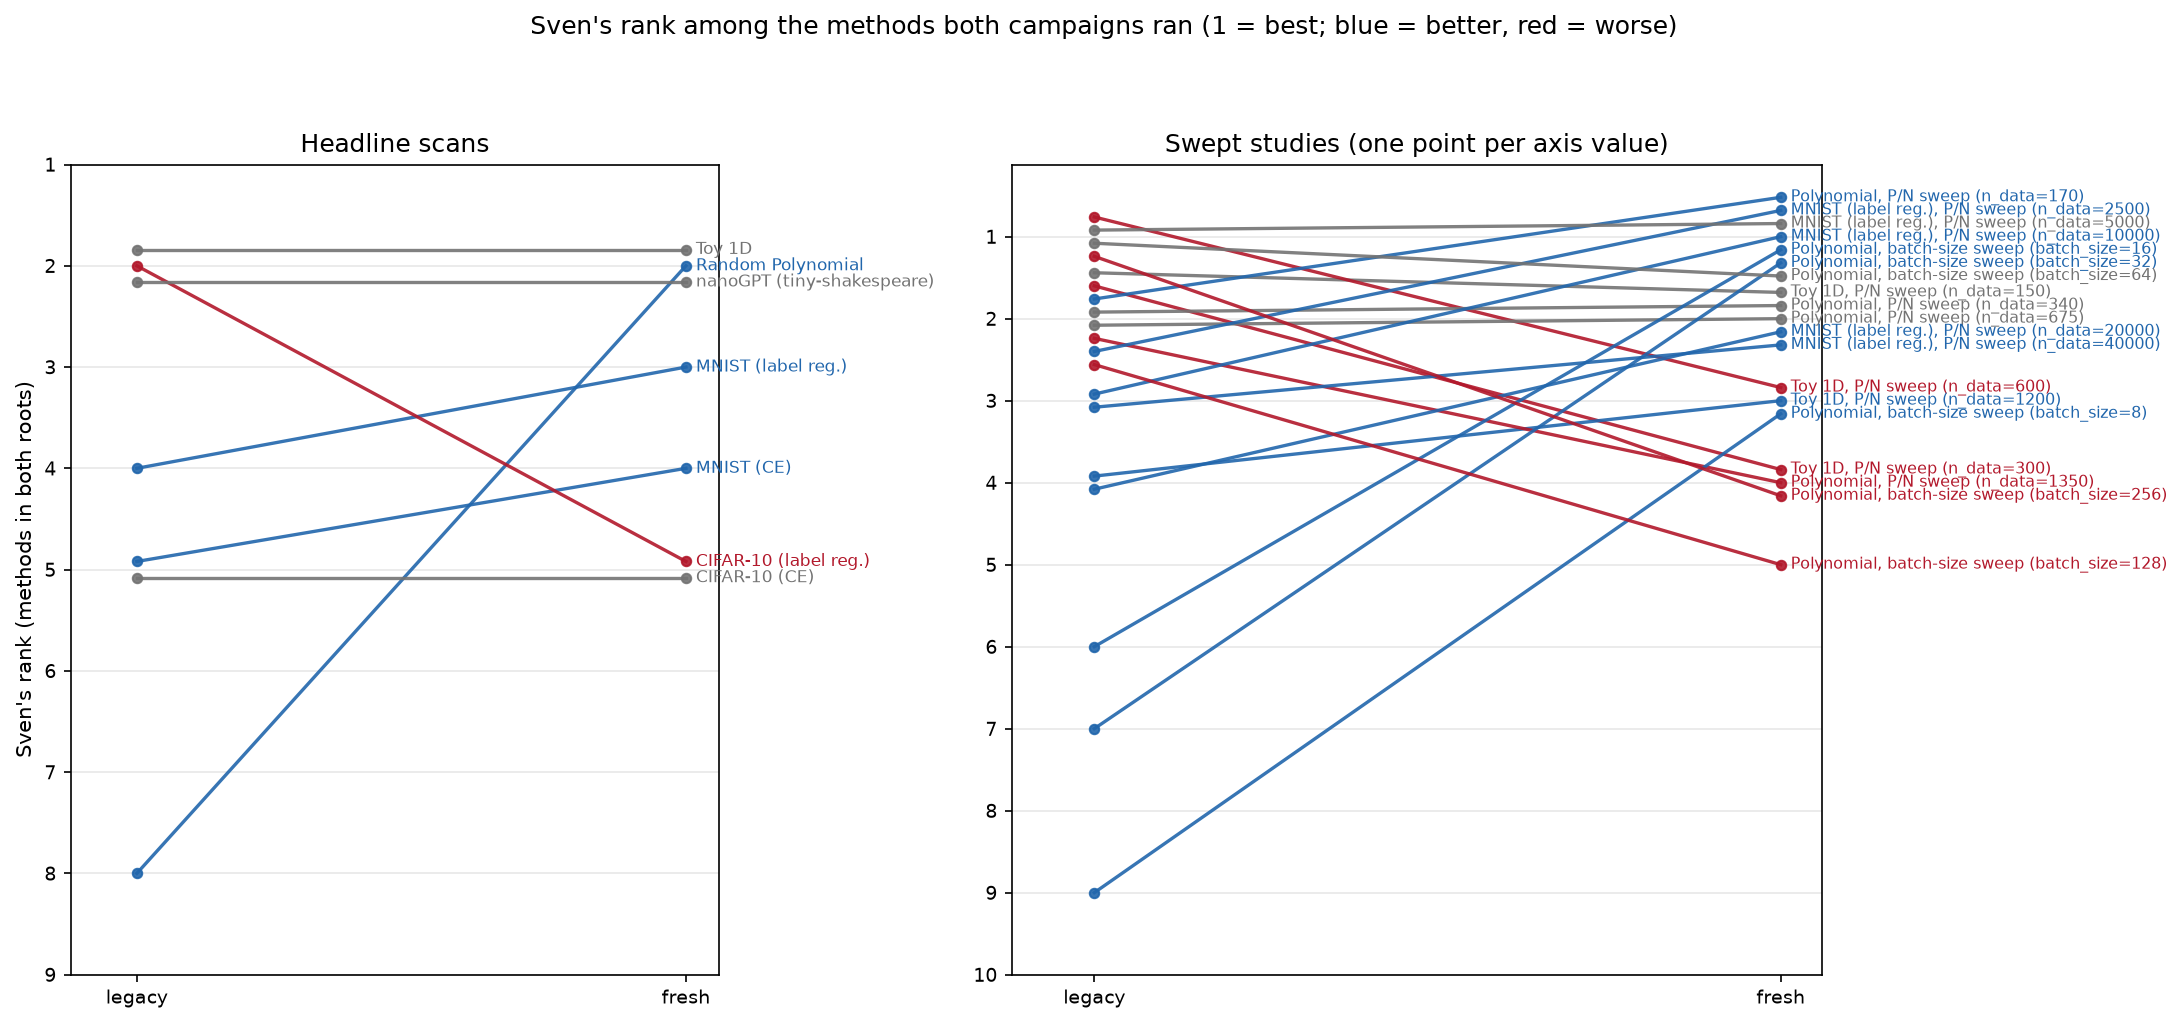

In [19]:
# Figure 1: the rank change, one line per comparable point.  Points that share a rank are
# fanned out so the labels are readable; the label colour is the direction of the change.
fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [1, 1.25]})
head = SUMMARY[SUMMARY['axis'] == ''].copy()
rest = SUMMARY[SUMMARY['axis'] != ''].copy()
ld.plot_rank_slope(head, axes[0])
axes[0].set_title('Headline scans', fontsize=12)
ld.plot_rank_slope(rest, axes[1], label_size=7.5)
axes[1].set_title('Swept studies (one point per axis value)', fontsize=12)
axes[1].set_ylabel('')
fig.suptitle("Sven's rank among the methods both campaigns ran (1 = best; blue = better, "
             "red = worse)", fontsize=12)
fig.subplots_adjust(right=0.78)
fig.tight_layout(rect=(0, 0, 0.99, 0.96))
ld.savefig(fig, 'sven_rank_legacy_vs_fresh')
plt.show()

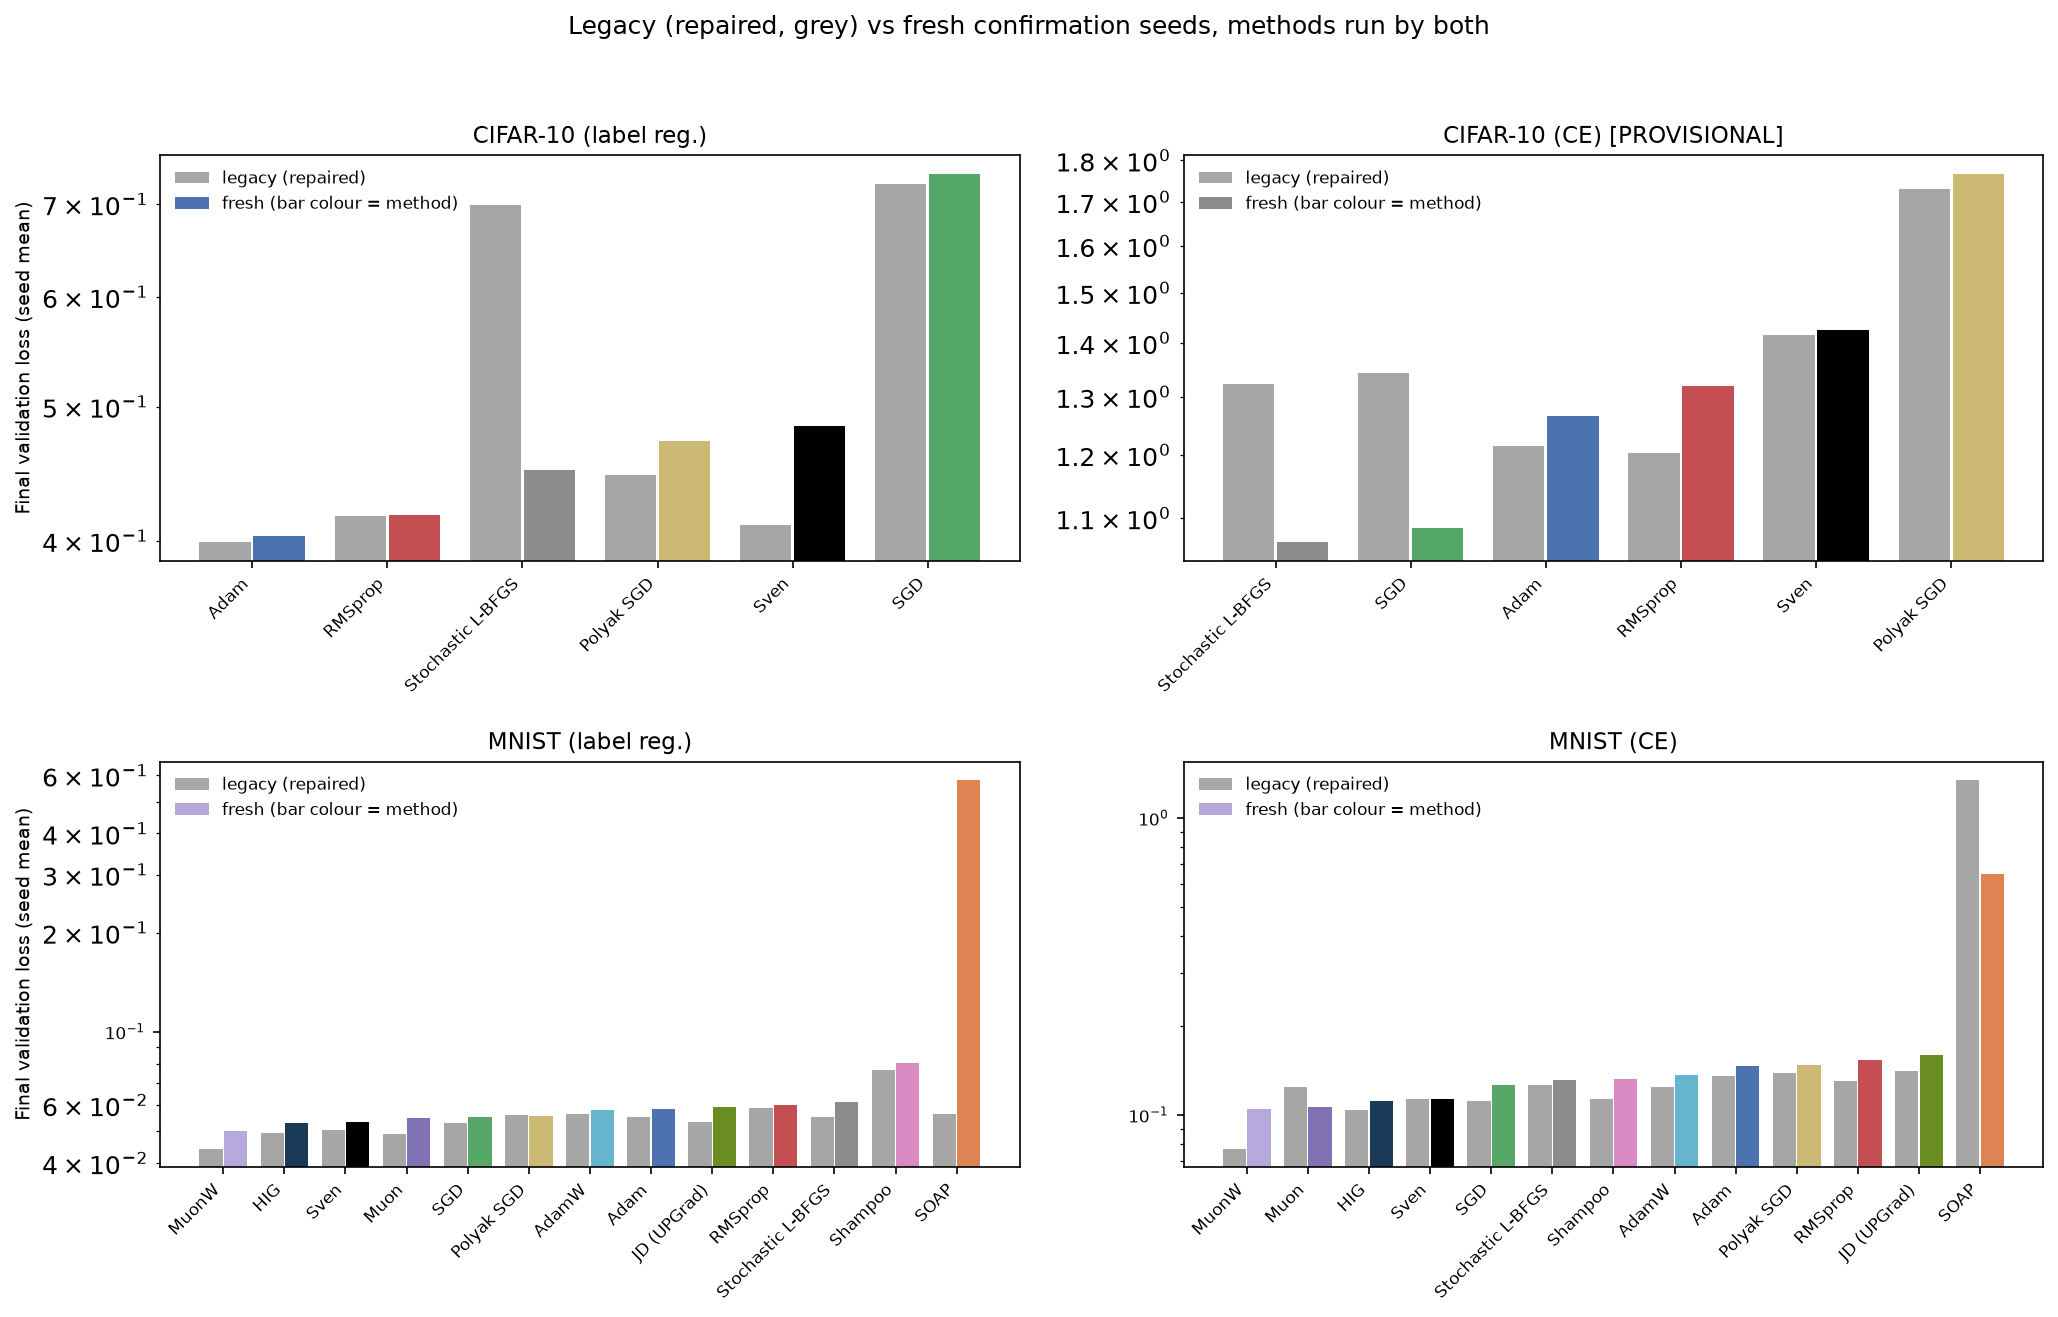

In [20]:
# Figure 2: where the level moved, per method, on the two scans the BatchNorm fix touches
# and the two it does not.  Bars are seed means of the final validation loss: legacy
# (repaired) grey, fresh confirmation in the method's colour (Sven black).
scans = ('cifar10_resnet_scan_labelRegression', 'cifar10_resnet_ce_scan',
         'mnist_scan_labelRegression', 'mnist_scan_ce')
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, (ax, scan) in enumerate(zip(axes.ravel(), scans)):
    ld.plot_method_deltas(DIFFS[scan], ax, ylabel='Final validation loss (seed mean)'
                          if i % 2 == 0 else '')
    ax.set_title(ld.scan_title(scan) + (' [PROVISIONAL]' if scan in PROVISIONAL else ''),
                 fontsize=11)
fig.suptitle('Legacy (repaired, grey) vs fresh confirmation seeds, methods run by both',
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
ld.savefig(fig, 'method_levels_legacy_vs_fresh')
plt.show()

## 7. Provenance of the legacy numbers

The join coverage of the example-weighted repair, per headline scan: what fraction of the
*usable* legacy runs (not diverged, not failed) carried a repaired value. Anything below 100 %
would mean a configuration's seed mean silently lost a seed.

In [21]:
cov = pd.DataFrame(COVERAGE.values())[['title', 'scan', 'source', 'n_runs', 'n_usable',
                                       'coverage', 'median_corr_%', 'max_corr_%']]
hl.print_table(cov, 'Legacy metric provenance, per headline scan')
repaired = cov[cov['coverage'].notna()]
assert (repaired['coverage'] == 1.0).all(), 'a usable legacy run has no repaired value'
print(f'\n[ok] every usable legacy run in {len(repaired)} of {len(cov)} headline scans carries '
      f'an example-weighted value; the rest fall back to the recorded, batch-averaged number '
      f'and are marked in their table.')


### Legacy metric provenance, per headline scan
| title | scan | source | n_runs | n_usable | coverage | median_corr_% | max_corr_% |
|---|---|---|---|---|---|---|---|
| Toy 1D | toy_1d_scan | example-weighted repair (/n/home11/sambt/iaifi/sv3/analysis/legacy_repair/toy_1d_scan.parquet) | 734 | 639 | 1 | 0.06442 | 0.9826 |
| Random Polynomial | polynomial_scan | example-weighted repair (/n/home11/sambt/iaifi/sv3/analysis/legacy_repair/polynomial_scan.parquet) | 731 | 637 | 1 | 0.09664 | 1.699 |
| MNIST (label reg.) | mnist_scan_labelRegression | example-weighted repair (/n/home11/sambt/iaifi/sv3/analysis/legacy_repair/mnist_scan_labelRegression.parquet) | 999 | 899 | 1 | 0.2777 | 0.5951 |
| MNIST (CE) | mnist_scan_ce | example-weighted repair (/n/home11/sambt/iaifi/sv3/analysis/legacy_repair/mnist_scan_ce.parquet) | 1040 | 1005 | 1 | 0.4164 | 0.7795 |
| CIFAR-10 (label reg.) | cifar10_resnet_scan_labelRegression | example-weighted repair (/n/home11/sambt/iaifi/sv3/analysis/legacy_repa

## 8. Caveats this notebook cannot remove

* **One legacy instance.** Toy and polynomial were single draws (`data_seed` fixed, F27); the
  fresh confirmation pass adds two more instances. A fresh confirmation mean therefore pools
  three problems against the legacy one, which is why the tables also carry the fresh
  *tuning-seed* rank on the single tuning instance.
* **Different seed counts.** Legacy = 5 tuning seeds; fresh = 5 tuning seeds **and** 5 fresh
  confirmation seeds (15 runs on toy/polynomial, over 3 data seeds).
* **Different validation data.** Every MNIST/CIFAR legacy number is on the official test set,
  every fresh one on a held-out slice of train; toy/polynomial validation comes from a different
  generator. Levels are not directly comparable — ranks are the signal.
* **Different hardware.** The scans ran mostly on MIG A100-40GB slices, the confirmation and
  timing passes partly on full A100-80GB. Muon, L-BFGS, SOAP/Shampoo/HIG and every CIFAR run are
  not bit-reproducible across the two, and MNIST Sven deviates by 1e-3…4e-2. Nothing here is a
  bit-level comparison.
* **A rank is not a margin.** Several of the changes below are a few per cent of loss between
  methods whose seed bands overlap; `analysis/headline.py`'s paired differences are the place
  where that is quantified.